## Project 1: The Monty Hall Paradox Simulator

**Objective:** Use empirical probability simulation to test the Monty Hall problem and observe how conditional probability alters outcome probabilities over thousands of trials.

* **Stay Strategy:** Wins only if the player's initial random choice happens to match the winning door ($P(\text{Win}) \approx 1/3$).
* **Switch Strategy:** Wins whenever the player's initial choice was *wrong*, because the host's revelation forces the remaining winning door into the player's hand ($P(\text{Win}) \approx 2/3$).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_monty_hall(num_trials=1000):
    #1 Randomly assign winning doors (0, 1, or 2) for each trial
    winning_doors = np.random.randint(0,3,size=num_trials)

    # 2. Simulate player's initial choice(0,1, or 2)
    player_choices = np.random.randint(0,3, size=num_trials)

    # 3. Calculate wins for 'Stay' strategy (player stays with initial choice)
    stay_wins = np.sum(player_choices == winning_doors)

    # 3. Calculate wins for 'Switch' strategy (player wins when initial choice was incorrect)
    switch_wins = np.sum(player_choices != winning_doors)

    # calculate empirical probabilities
    prob_stay = stay_wins / num_trials
    prob_switch = switch_wins / num_trials

    print(f"Total Trials: {num_trials}")
    print(f"Empirical Win Probability (Stay): {prob_stay:.4f} (~33.3%)")
    print(f"Empirical win Probability (Switch): {prob_switch:.4f} (~67.7%)")

    return prob_stay, prob_switch

simulate_monty_hall(10000000)

Total Trials: 10000000
Empirical Win Probability (Stay): 0.3336 (~33.3%)
Empirical win Probability (Switch): 0.6664 (~67.7%)


(np.float64(0.3336307), np.float64(0.6663693))

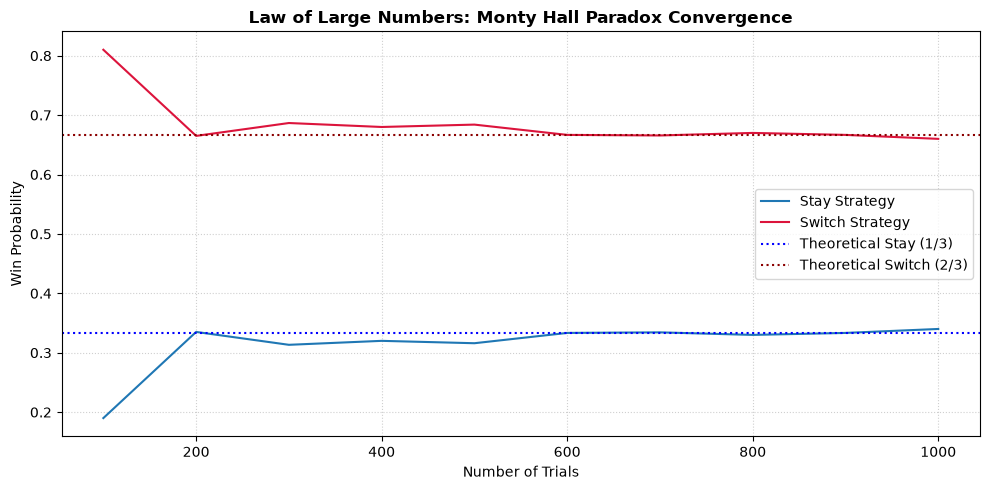

In [10]:
# Plot convergence across increasing trial sizes to watch the Law of Large Numbers in action
trial_sizes = np.arange(100, 1001, 100)
stay_probs = []
switch_probs = []

for n in trial_sizes:
    winning_doors = np.random.randint(0, 3, size=n)
    player_choices = np.random.randint(0, 3, size=n)

    stay_probs.append(np.sum(player_choices == winning_doors) / n)
    switch_probs.append(np.sum(player_choices != winning_doors) / n)

plt.figure(figsize=(10, 5))
plt.plot(trial_sizes, stay_probs, label="Stay Strategy", color="#1f77b4", lw=1.5)
plt.plot(trial_sizes, switch_probs, label="Switch Strategy", color="crimson", lw=1.5)
plt.axhline(1/3, color="blue", linestyle=":", label="Theoretical Stay (1/3)")
plt.axhline(2/3, color="darkred", linestyle=":", label="Theoretical Switch (2/3)")

plt.title("Law of Large Numbers: Monty Hall Paradox Convergence", fontsize=12, fontweight="bold")
plt.xlabel("Number of Trials")
plt.ylabel("Win Probability")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="right")
plt.tight_layout()
plt.show()